In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import os

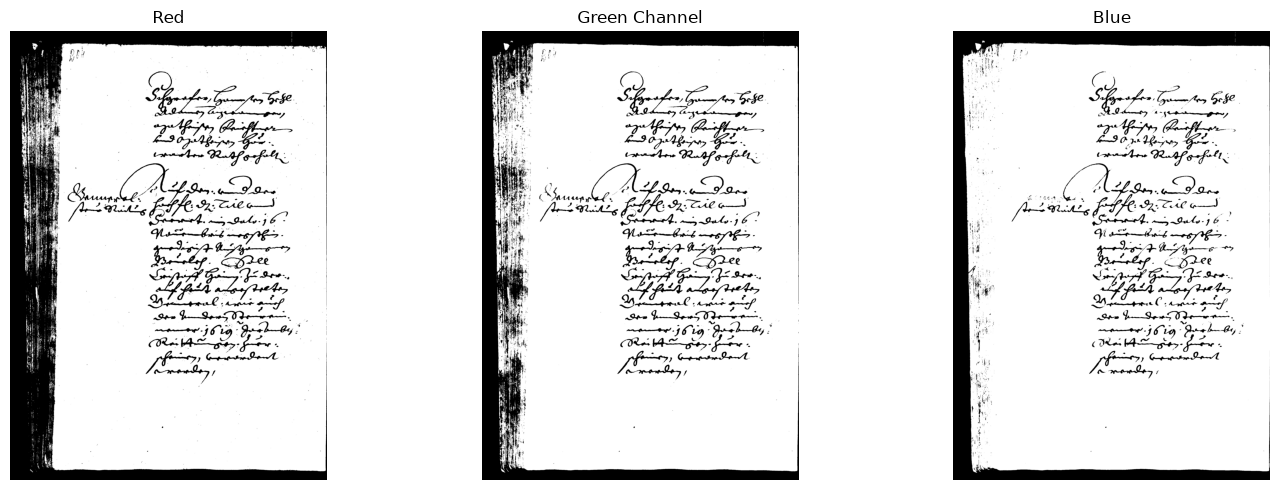

In [2]:
image_id = "Seite0406"
img_path = f"../../../DATASETS/READ_2016/test/Images/{image_id}.JPG"
gt_path = f"../../../DATASETS/READ_2016/test/gt_xml"
label_path = "../../../DATASETS/READ_2016/test/labels"  #Path for Hi-SAM genrated binary images
# Load the image (OpenCV loads in BGR order)
image = cv2.imread(img_path)
if image is None:
    raise ValueError("Image not found!")

H, W, _ = image.shape
# Convert to RGB for plotting with matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Apply Otsu's thresholding on green channel
_, binary = cv2.threshold(image[:, :, 0], 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

axs[0].imshow(binary, cmap="gray")
axs[0].set_title("Red")
axs[0].axis("off")

_, binary = cv2.threshold(image[:, :, 1], 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
axs[1].imshow(binary, cmap="gray")
axs[1].set_title("Green Channel")
axs[1].axis("off")

_, binary = cv2.threshold(image[:, :, 2], 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
axs[2].imshow(binary, cmap="gray")
axs[2].set_title("Blue")
axs[2].axis("off")

plt.tight_layout()
plt.show()


# Get GT masks

In [3]:
def safeguard_points(points, w, h):
    """
    Ensure that all (x, y) points are within image bounds.
    """
    safeguarded = [(max(0, min(x, w - 1)), max(0, min(y, h - 1))) for x, y in points]
    return safeguarded

def get_GT_Boxes_onePage(gt_path, image_id):
    tree = ET.parse(os.path.join(gt_path, f"{image_id}.xml"))
    root = tree.getroot()
    ns = {'pc': 'http://schema.primaresearch.org/PAGE/gts/pagecontent/2013-07-15'}
    w = int(root.find("pc:Page", ns).attrib['imageWidth'])
    h = int(root.find("pc:Page", ns).attrib['imageHeight'])
    
    ## Extract GT Points ######################
    gt_points = []
    for line in root.findall(".//pc:TextLine", ns):
        coords_elem = line.find("pc:Coords", ns)
        points_str = coords_elem.attrib['points']
        points = [tuple(map(int, p.split(','))) for p in points_str.split()]
        points = safeguard_points(points, w, h)
        gt_points.append(points)
        
    return  gt_points

def expand_polygon(boxes_coords, scale=1.1):
    expanded_boxes = []
    for coords in boxes_coords:
        coords_np = np.array(coords, dtype=np.float32)
        centroid = coords_np.mean(axis=0)
        expanded = centroid + scale * (coords_np - centroid)
        expanded = expanded.astype(int).tolist()
        expanded_boxes.append(expanded)
    return expanded_boxes
        
def box_to_mask(H, W, boxes):
    masks = []
    for box in boxes:
        mask = np.zeros((H, W), dtype=np.uint8)
        pts = np.array(box, dtype=np.int32)
        pts = pts.reshape((-1, 1, 2))
        cv2.fillPoly(mask, [pts], 1)
        masks.append(mask)
    return np.array(masks)

def apply_mask_binary(image, combined_mask):
    result = image.copy()
    result = 255 - result
    inverted_mask = 1 - combined_mask
    inverted_mask = (inverted_mask > 0).astype(np.uint8)
    result[inverted_mask == 1] = 0  # if binary {0,1}
    return result


(np.float64(-0.5), np.float64(2479.5), np.float64(3510.5), np.float64(-0.5))

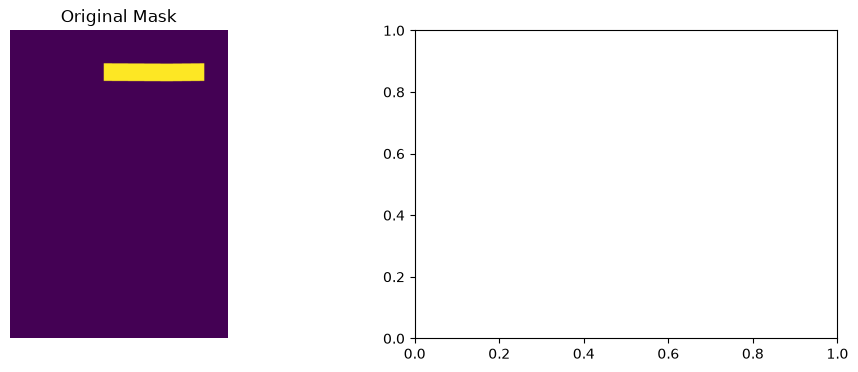

In [6]:
gt_boxes = get_GT_Boxes_onePage(gt_path, image_id)

masks = box_to_mask(H, W, gt_boxes)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(masks[1])
axes[0].set_title("Original Mask")
axes[0].axis("off")


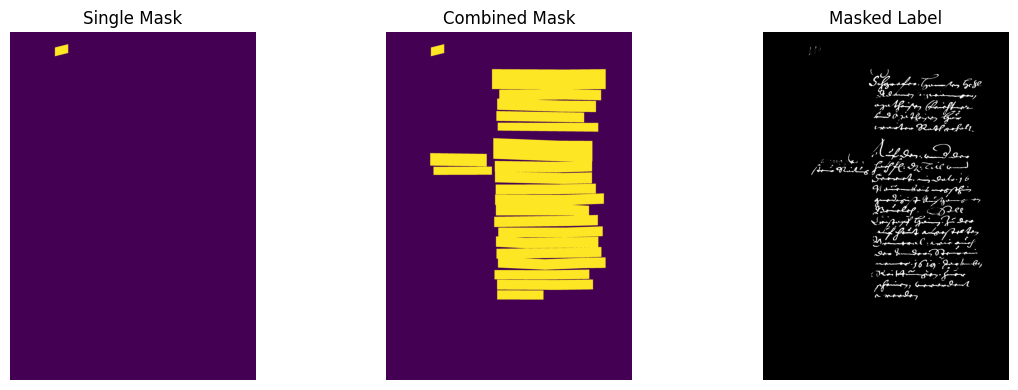

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(masks[0])
axes[0].set_title("Single Mask")
axes[0].axis("off")

combined_mask = np.max(masks, axis=0)

axes[1].imshow(combined_mask)
axes[1].set_title("Combined Mask")
axes[1].axis("off")

masked_label = apply_mask_binary(binary, combined_mask)

axes[2].imshow(masked_label, cmap="gray")
axes[2].set_title("Masked Label")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# cv2.imwrite(f"{image_id}_otsu.png", masked_label)

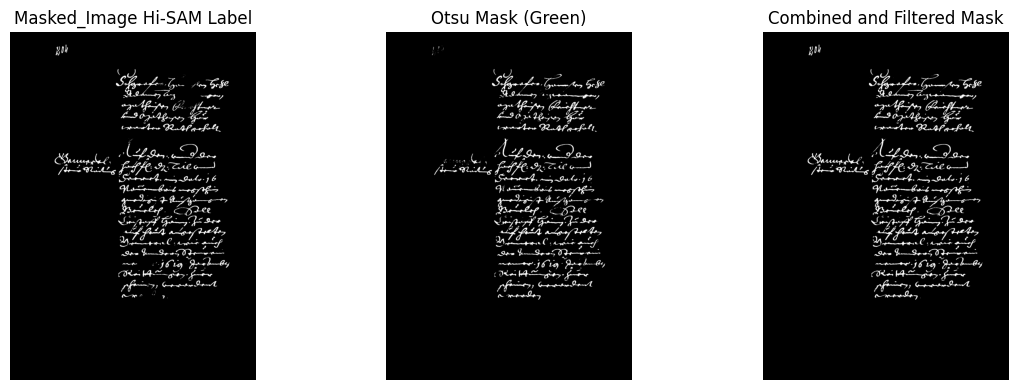

In [27]:
hi_label = cv2.imread(f"{label_path}/{image_id}.png" , cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

hi_label = 255 - hi_label
masked_hi_label = apply_mask_binary(hi_label, combined_mask)

axes[0].imshow(masked_hi_label, cmap="gray")
axes[0].set_title("Masked_Image Hi-SAM Label")
axes[0].axis("off")

axes[1].imshow(masked_label, cmap="gray")
axes[1].set_title("Otsu Mask (Green)")
axes[1].axis("off")

both_masks = np.array([masked_label, masked_hi_label])

new_mask = np.max(both_masks, axis=0)

axes[2].imshow(new_mask, cmap="gray")
axes[2].set_title("Combined and Filtered Mask")
axes[2].axis("off")

plt.tight_layout()

# Save image
# plt.savefig(
#     "comparison_masks.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

# Final Pipeline

In [23]:
def imread_unicode(path, color_prof=cv2.IMREAD_COLOR):
    with open(path, "rb") as f:
        data = np.frombuffer(f.read(), np.uint8)
    return cv2.imdecode(data, color_prof)


In [29]:
# image_id = "Seite0003"
split = "test"
root = "../../../DATASETS/READ_2016"
ext="JPG"

img_root = f"{root}/{split}/Images"
gt_path = f"{root}/{split}/gt_xml"
label_path = f"{root}/{split}/labels"
# new_label_path1 = f"{root}/{split}/bin_masks_hi-sam"
new_label_path2 = f"{root}/{split}/bin_masks_otsu_hi-sam2"
# os.makedirs(new_label_path1, exist_ok=True)
os.makedirs(new_label_path2, exist_ok=True)

# for fname in os.listdir(img_root):
#     if fname.lower().endswith(f".{ext}"):
#         image_id = os.path.splitext(fname)[0]
#         print(image_id)

#         # Load the image
image_id = "Seite0406"
img_path = f"{img_root}/{image_id}.{ext}"
image = cv2.imread(img_path)
H, W, _ = image.shape

#Create Otsu based binary mask
# Extract green channel
green_channel = image[:, :, 1]
_, binary = cv2.threshold(green_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

gt_boxes = get_GT_Boxes_onePage(gt_path, image_id)
masks = box_to_mask(H, W, gt_boxes)

combined_mask = np.max(masks, axis=0)
# Filter Otsu binary mask by the GT polygones
masked_label = apply_mask_binary(binary, combined_mask)


hi_label = cv2.imread(f"{label_path}/{image_id}.png" , cv2.IMREAD_GRAYSCALE)

# Filter Hi-SAM binary mask by the GT polygones
hi_label = 255 - hi_label
masked_hi_label = apply_mask_binary(hi_label, combined_mask)
# cv2.imwrite(f"{new_label_path1}/{image_id}.png", masked_hi_label)

#Conbine both Otsu and Hi-SAM binary masks
both_masks = np.array([masked_label, masked_hi_label])
new_mask = np.max(both_masks, axis=0)

cv2.imwrite(f"{new_label_path2}/{image_id}.png", new_mask)

True